In [23]:
#https://github.com/marcharper/python-ternary
#pip install python-ternary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path="../data/"
select_cols=["xA", "yA", "zA", "xC", "yC", "zC", "rA", "rB", "rC", "TF", "OF", "Eg", "duplicated"]
df = pd.read_csv(data_path+"prepared_data_Sona.csv")#[select_cols]
df.head()

,Unnamed: 0,rownum,A1,A2,A3,B,C1,C2,C3,xA,...,rA3,rA,rB,rC1,rC2,rC3,rC,TF,OF,duplicated
0,10,11.0,Cs,MA,FA,Pb,Cl,Br,I,0.0,...,2.53,2.16,1.19,1.81,1.96,2.2,1.8100,0.935738,0.657459,0
1,11,12.0,Cs,MA,FA,Pb,Cl,Br,I,0.0,...,2.53,2.16,1.19,1.81,1.96,2.2,1.8595,0.932027,0.639957,0
2,12,13.0,Cs,MA,FA,Pb,Cl,Br,I,0.0,...,2.53,2.16,1.19,1.81,1.96,2.2,1.9525,0.925370,0.609475,0
3,13,14.0,Cs,MA,FA,Pb,Cl,Br,I,0.0,...,2.53,2.16,1.19,1.81,1.96,2.2,1.9570,0.925058,0.608074,0
4,14,15.0,Cs,MA,FA,Pb,Cl,Br,I,0.0,...,2.53,2.16,1.19,1.81,1.96,2.2,1.9600,0.924851,0.607143,0


### checking the data

In [26]:
##removinգ the suspicious rows
#df = df[~((df["duplicated"]==1)&(df["Eg"]==2.2))]

In [3]:
import math
from matplotlib import pyplot as plt
import ternary
from ternary.helpers import simplex_iterator

def calculate_r(x, y, z, scale, r1, r2, r3):
    x_color = x / float(scale)
    y_color = y / float(scale)
    z_color = z / float(scale)
    fi = x_color*r1 +  y_color*r2 +  z_color*r3
    return fi


def generate_heatmap_data_for_r(scale, r1, r2, r3):
    d = dict()
    for (i, j, k) in simplex_iterator(scale):
        d[(i, j, k)] = calculate_r(i, j, k, scale, r1, r2, r3)
    return d

fontsize=12
offset = 0.14
scale = 20

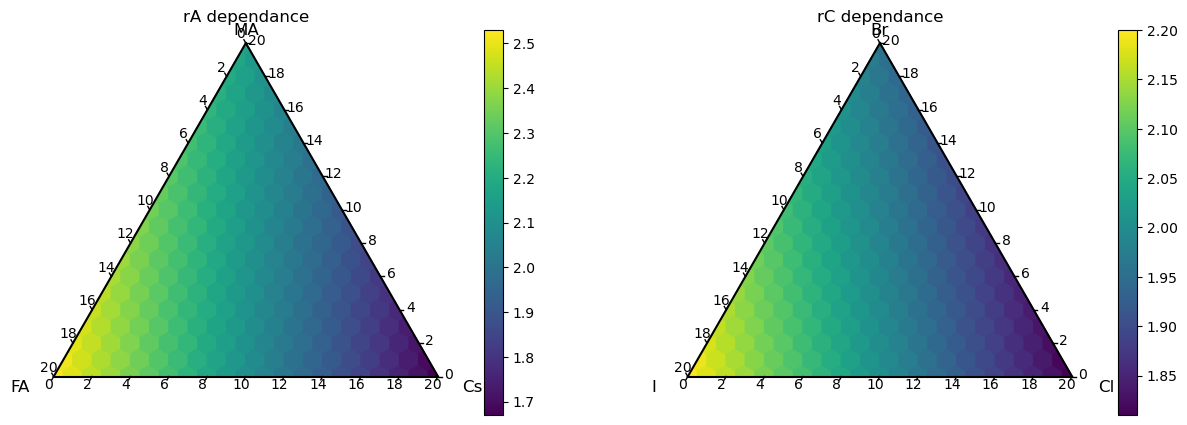

In [4]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
data = generate_heatmap_data_for_r(scale, df.loc[0, "rA1"], df.loc[0, "rA2"], df.loc[0, "rA3"])
figure, tax = ternary.figure(ax = ax[0], scale = scale)
##figure, tax = ternary.figure(scale=scale)
tax.heatmap(data, style="hexagonal", use_rgba=False)
tax.boundary()
tax.right_corner_label("Cs", fontsize=fontsize, offset=offset)
tax.top_corner_label("MA", fontsize=fontsize, offset=offset)
tax.left_corner_label("FA", fontsize=fontsize, offset=offset)
tax.set_title("rA dependance")
#tax.set_axis_limits({'b': [0, 20], 'l': [0, 20], 'r': [0, 20]})
# get and set the custom ticks:
#tax.get_ticks_from_axis_limits()
#tax.set_custom_ticks([0,2,4,6,8,10,12,14,16,18,20], [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], fontsize=10, offset=0.02)
tax.ticks(axis='lbr', linewidth=1, multiple=2)# tick_formats="%.1f"
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
#tax.show()
data = generate_heatmap_data_for_r(scale, df.loc[0, "rC1"], df.loc[0, "rC2"], df.loc[0, "rC3"])
figure, tax = ternary.figure(ax = ax[1], scale=scale)
tax.heatmap(data, style="hexagonal", use_rgba=False)
tax.boundary()
tax.right_corner_label("Cl", fontsize=fontsize, offset=offset)
tax.top_corner_label("Br", fontsize=fontsize, offset=offset)
tax.left_corner_label("I", fontsize=fontsize, offset=offset)
tax.set_title("rC dependance")
tax.ticks(axis='lbr', linewidth=1, multiple=2)
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
#tax.show()

In [29]:
###same r values can be achieved through different values of x,y,z, so x,y,z should also be included in the model

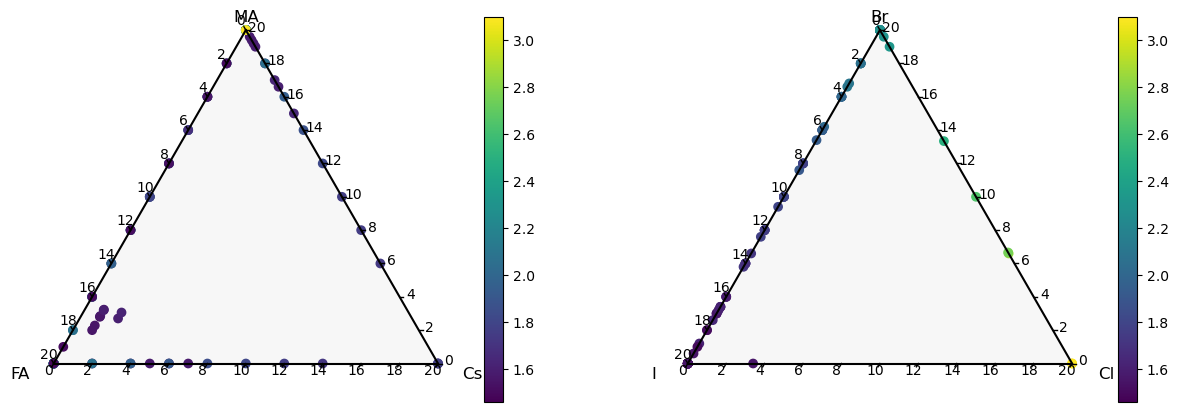

In [5]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
figure, tax = ternary.figure(ax=ax[0], scale=scale)
points = []
colors = []
for ind, row in df.iterrows():
    points.append((row["xA"]*20, row["yA"]*20, row["zA"]*20))
    colors.append(row["Eg"])
tax.scatter(points, vmax=max(colors), vmin=min(colors), colormap=plt.cm.viridis, colorbar=True, c=colors, cmap=plt.cm.viridis)
tax.boundary()
tax.right_corner_label("Cs", fontsize=fontsize, offset=offset)
tax.top_corner_label("MA", fontsize=fontsize, offset=offset)
tax.left_corner_label("FA", fontsize=fontsize, offset=offset)
#tax.set_title("Eg dependance")
tax.ticks(axis='lbr', linewidth=1, multiple=2)
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
#tax.show()
figure, tax = ternary.figure(ax=ax[1], scale=scale)
points = []
colors = []
for ind, row in df.iterrows():
    points.append((row["xC"]*20, row["yC"]*20, row["zC"]*20))
    colors.append(row["Eg"])
tax.scatter(points, vmax=max(colors), vmin=min(colors), colormap=plt.cm.viridis, colorbar=True, c=colors, cmap=plt.cm.viridis)
tax.boundary()
tax.right_corner_label("Cl", fontsize=fontsize, offset=offset)
tax.top_corner_label("Br", fontsize=fontsize, offset=offset)
tax.left_corner_label("I", fontsize=fontsize, offset=offset)
#tax.set_title("Eg dependance")
tax.ticks(axis='lbr', linewidth=1, multiple=2)
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
#tax.show()
#plt.tight_layout()

In [6]:
df.groupby(["xC", "yC", "zC"]).count()

Unnamed: 0  rownum  A1  A2  A3   B  C1  C2  C3  xA  ...  \
xC    yC    zC                                                        ...   
0.000 0.000 0.00           5       0   0   0   0   0   0   0   0   5  ...   
            1.00          34      34  34  34  34  34  34  34  34  34  ...   
      0.030 0.97           1       1   1   1   1   1   1   1   1   1  ...   
      0.050 0.95           1       1   1   1   1   1   1   1   1   1  ...   
      0.060 0.94           1       1   1   1   1   1   1   1   1   1  ...   
      0.100 0.90           2       2   2   2   2   2   2   2   2   2  ...   
      0.130 0.87           1       1   1   1   1   1   1   1   1   1  ...   
      0.150 0.85           3       3   3   3   3   3   3   3   3   3  ...   
      0.160 0.84           1       1   1   1   1   1   1   1   1   1  ...   
      0.170 0.83           3       3   3   3   3   3   3   3   3   3  ...   
      0.200 0.80           3       3   3   3   3   3   3   3   3   3  ...   
      0.290 0.71           1       1   1   1   1   1   1   1   1   1  ...   
      0.300 0.70           4       4   4   4   4   4   4   4   4   4  ...   
      0.330 0.67           1       1   1   1   1   1   1   1   1   1  ...   
      0.380 0.62           1       1   1   1   1   1   1   1   1   1  ...   
      0.400 0.60           4       4   4   4   4   4   4   4   4   4  ...   
      0.470 0.53           1       1   1   1   1   1   1   1   1   1  ...   
      0.500 0.50           5       5   5   5   5   5   5   5   5   5  ...   
      0.580 0.42           1       1   1   1   1   1   1   1   1   1  ...   
      0.600 0.40           5       5   5   5   5   5   5   5   5   5  ...   
      0.670 0.33           1       1   1   1   1   1   1   1   1   1  ...   
      0.700 0.30           4       4   4   4   4   4   4   4   4   4  ...   
      0.710 0.29           1       1   1   1   1   1   1   1   1   1  ...   
      0.800 0.20           4       4   4   4   4   4   4   4   4   4  ...   
      0.830 0.17           1       1   1   1   1   1   1   1   1   1  ...   
      0.840 0.16           1       1   1   1   1   1   1   1   1   1  ...   
      0.900 0.10           4       4   4   4   4   4   4   4   4   4  ...   
      1.000 0.00          18      18  18  18  18  18  18  18  18  18  ...   
0.020 0.980 0.00           1       1   1   1   1   1   1   1   1   1  ...   
0.050 0.950 0.00           1       1   1   1   1   1   1   1   1   1  ...   
0.170 0.000 0.83           1       1   1   1   1   1   1   1   1   1  ...   
0.333 0.667 0.00           1       1   1   1   1   1   1   1   1   1  ...   
0.500 0.500 0.00           1       1   1   1   1   1   1   1   1   1  ...   
0.667 0.333 0.00           1       1   1   1   1   1   1   1   1   1  ...   
0.670 0.330 0.00           1       1   1   1   1   1   1   1   1   1  ...   
1.000 0.000 0.00           2       2   2   2   2   2   2   2   2   2  ...   

                  rA3  rA  rB  rC1  rC2  rC3  rC  TF  OF  duplicated  
xC    yC    zC                                                        
0.000 0.000 0.00    5   5   5    5    5    5   5   5   5           5  
            1.00   34  34  34   34   34   34  34  34  34          34  
      0.030 0.97    1   1   1    1    1    1   1   1   1           1  
      0.050 0.95    1   1   1    1    1    1   1   1   1           1  
      0.060 0.94    1   1   1    1    1    1   1   1   1           1  
      0.100 0.90    2   2   2    2    2    2   2   2   2           2  
      0.130 0.87    1   1   1    1    1    1   1   1   1           1  
      0.150 0.85    3   3   3    3    3    3   3   3   3           3  
      0.160 0.84    1   1   1    1    1    1   1   1   1           1  
      0.170 0.83    3   3   3    3    3    3   3   3   3           3  
      0.200 0.80    3   3   3    3    3    3   3   3   3           3  
      0.290 0.71    1   1   1    1    1    1   1   1   1           1  
      0.300 0.70    4   4   4    4    4    4   4   4   4           4  
      0.330 0.67    1   1 

In [8]:
###combinations
### 0,0,1
### 0,1,0

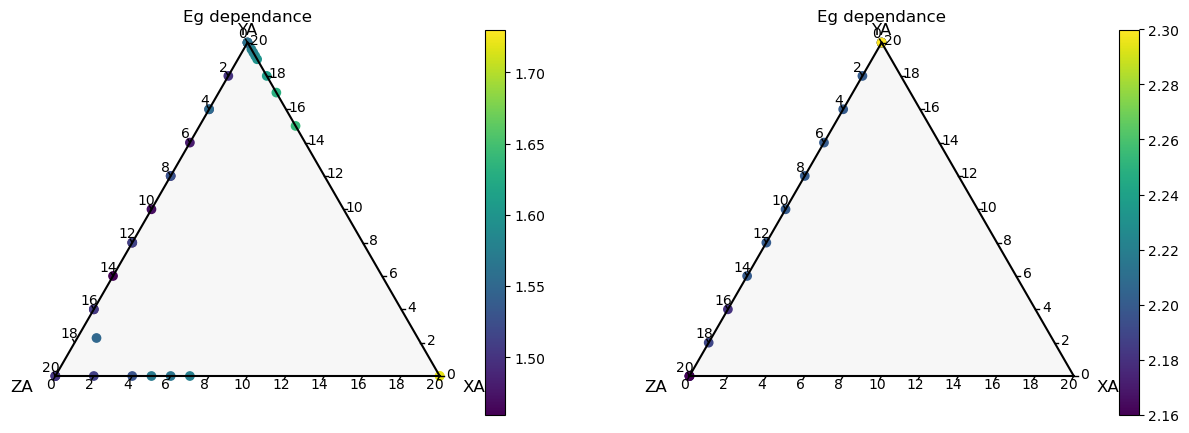

In [7]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
figure, tax = ternary.figure(ax=ax[0], scale=scale)
points = []
colors = []
for ind, row in df[(df["xC"]==0)&(df["yC"]==0)&(df["zC"]==1)][["xA", "yA", "zA", "Eg"]].iterrows():
    points.append((row["xA"]*20, row["yA"]*20, row["zA"]*20))
    colors.append(row["Eg"])
tax.scatter(points, vmax=max(colors), vmin=min(colors), colormap=plt.cm.viridis, colorbar=True, c=colors, cmap=plt.cm.viridis)
tax.boundary()
tax.right_corner_label("XA", fontsize=fontsize, offset=offset)
tax.top_corner_label("YA", fontsize=fontsize, offset=offset)
tax.left_corner_label("ZA", fontsize=fontsize, offset=offset)
tax.set_title("Eg dependance")
tax.ticks(axis='lbr', linewidth=1, multiple=2)
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()
figure, tax = ternary.figure(ax=ax[1], scale=scale)
points = []
colors = []
for ind, row in df[(df["xC"]==0)&(df["yC"]==1)&(df["zC"]==0)][["xA", "yA", "zA", "Eg"]].iterrows():
    points.append((row["xA"]*20, row["yA"]*20, row["zA"]*20))
    colors.append(row["Eg"])
tax.scatter(points, vmax=max(colors), vmin=min(colors), colormap=plt.cm.viridis, colorbar=True, c=colors, cmap=plt.cm.viridis)
tax.boundary()
tax.right_corner_label("XA", fontsize=fontsize, offset=offset)
tax.top_corner_label("YA", fontsize=fontsize, offset=offset)
tax.left_corner_label("ZA", fontsize=fontsize, offset=offset)
tax.set_title("Eg dependance")
tax.ticks(axis='lbr', linewidth=1, multiple=2)
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()

In [9]:
###Eg depends less on rA and more on rC?

<Axes: xlabel='rA', ylabel='rC'>

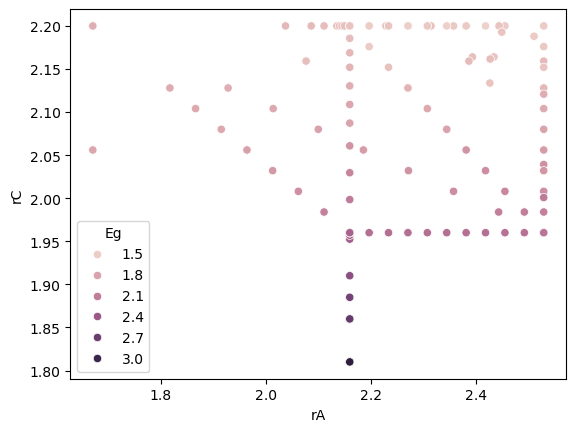

In [10]:
sns.scatterplot(data=df, x="rA", y="rC", hue="Eg")

In [11]:
###same conclusion as above

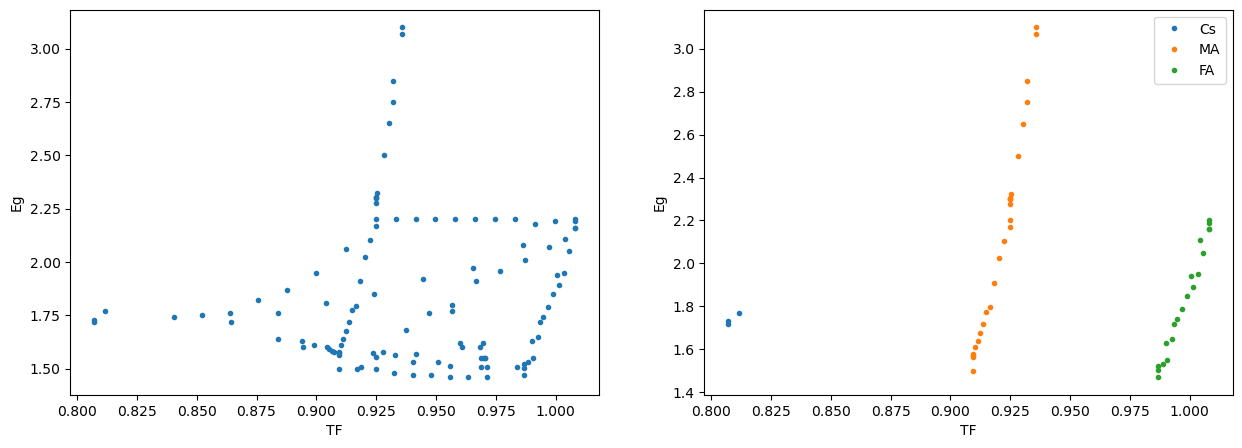

In [13]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ax[0].plot(df["TF"], df["Eg"], ".")
ax[0].set_xlabel("TF")
ax[0].set_ylabel("Eg")
ax[1].plot(df[df["xA"]==1]["TF"], df[df["xA"]==1]["Eg"], ".", label="Cs")
ax[1].plot(df[df["yA"]==1]["TF"], df[df["yA"]==1]["Eg"], ".", label="MA")
ax[1].plot(df[df["zA"]==1]["TF"], df[df["zA"]==1]["Eg"], ".", label="FA")
ax[1].set_xlabel("TF")
ax[1].set_ylabel("Eg")
plt.legend();

In [14]:
##the 'dependence' from TF seems to be mainly in the cutoff regionnear 1.7. the diagonal clear correlation on the right are due to rC.

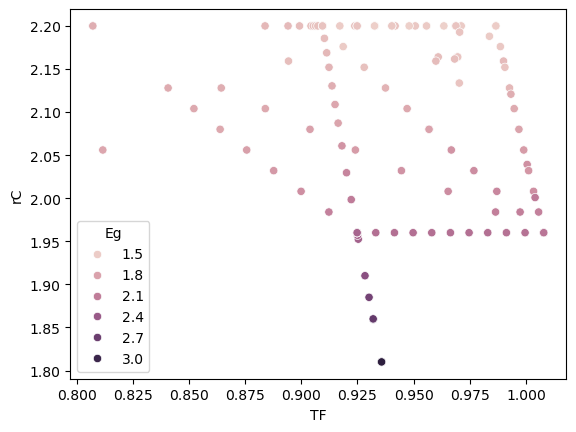

In [15]:
sns.scatterplot(data=df, x="TF", y="rC", hue="Eg");

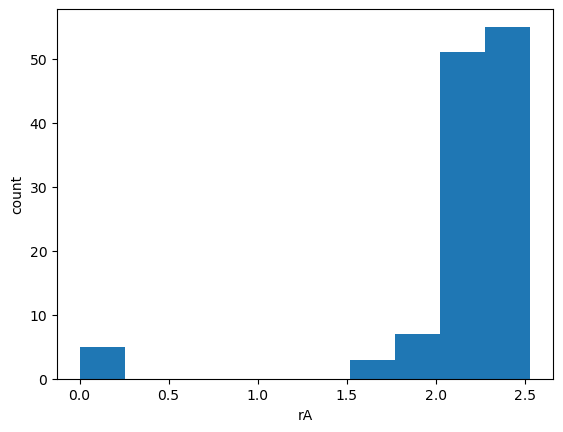

In [16]:
plt.hist(df["rA"])
plt.xlabel("rA")
plt.ylabel("count");

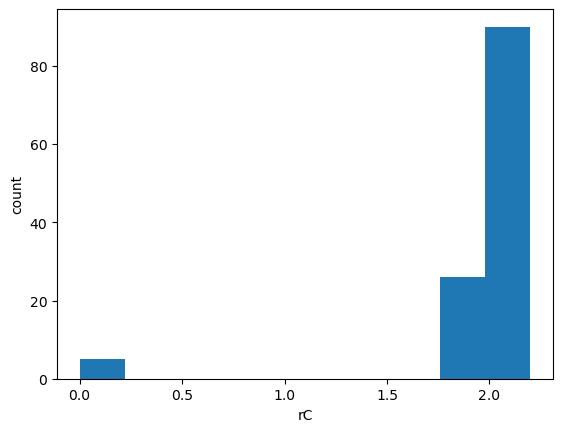

In [17]:
plt.hist(df["rC"])
plt.xlabel("rC")
plt.ylabel("count");

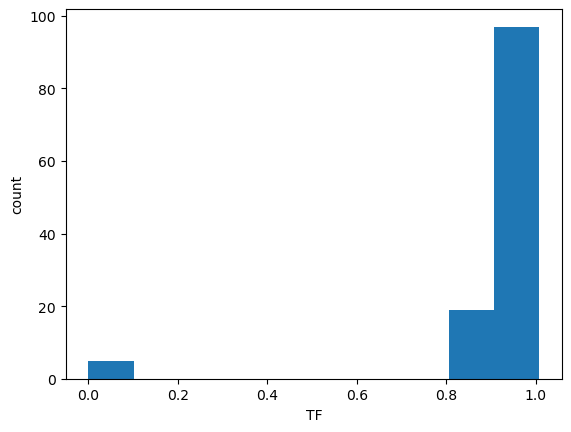

In [18]:
plt.hist(df["TF"])
plt.xlabel("TF")
plt.ylabel("count");

In [21]:
df['OF'].unique()

array([0.65745856, 0.63995698, 0.60947503, 0.60807358, 0.60714286,
       0.59547638, 0.58632243, 0.57744565, 0.57014182, 0.56430197,
       0.55858055, 0.55297398, 0.54869052, 0.54447291, 0.54090909,
       0.546875  , 0.55113005, 0.55921053, 0.56110902, 0.56558935,
       0.57211538, 0.57879377, 0.58356218, 0.58562992, 0.59262948,
       0.5947621 , 0.59979839, 0.54268515, 0.54990758, 0.54387569,
       0.55771664, 0.55051813, 0.62302034, 0.63129973, 0.63980215,
              inf])

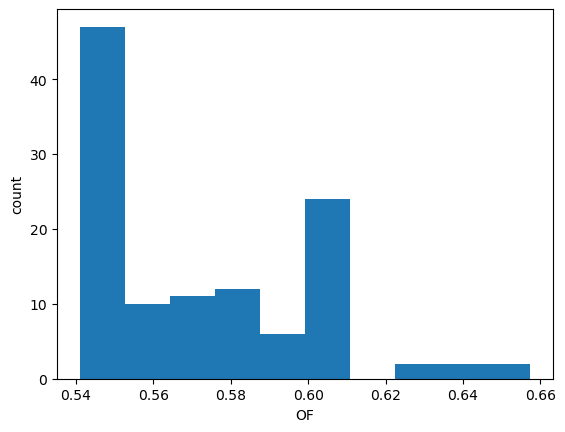

In [22]:
df_clean = df[np.isfinite(df["OF"])]

plt.hist(df_clean["OF"])
plt.xlabel("OF")
plt.ylabel("count")
plt.show()


<Axes: xlabel='OF', ylabel='rC'>

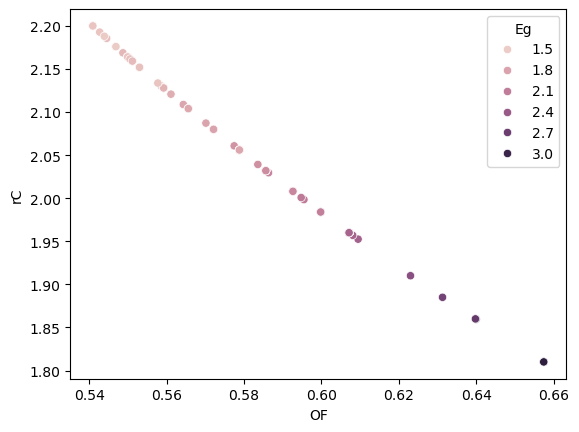

In [23]:
sns.scatterplot(data=df, x="OF", y="rC", hue="Eg")

Text(0, 0.5, 'Eg')

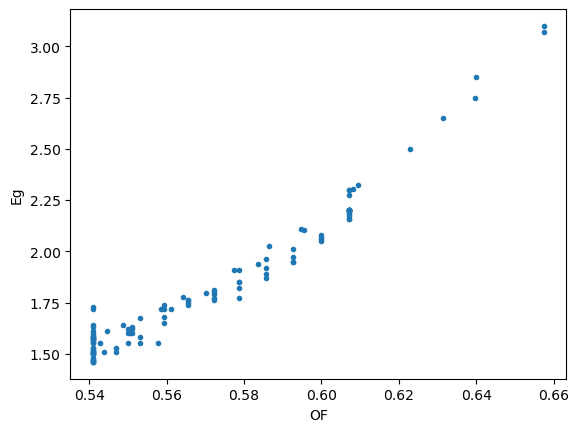

In [24]:
plt.plot(df["OF"], df["Eg"], ".")
plt.xlabel("OF")
plt.ylabel("Eg")

In [25]:
##Octahedral factor is equivalent to rC, need to exclude